# 2025 DL Lab3: Semi-Supervised Flower Classfication

Before we start, please put **your name** and **SID** in following format: <br>
Hi I'm 陸仁賈, 314831000.

**Your Answer:**    
Hi I'm 李朋逸, 314831024.

## Semi-supervised Flower Classfication

In this approach, you have a dataset that includes both labeled and unlabeled examples.

The goal is to use the labeled data to train the model while also leveraging the unlabeled
data to improve the model's performance.

In this assignment, you’ll explore a self-training mechanism for this task.


**Please note that you’re not allowed to use pre-constructed models or pre-trained weights.**

## Kaggle Competition
Kaggle is an online community of data scientists and machine learning practitioners. Kaggle allows users to find and publish datasets, explore and build models in a web-based data-science environment, work with other data scientists and machine learning engineers, and enter competitions to solve data science challenges.

This assignment use kaggle to calculate your grade.  
Please use this [**LINK**](https://www.kaggle.com/t/c835441092034e459933e0a304e469e1) to join the competition.


##  Versions of used packages

We will check PyTorch version to make sure everything work properly.

In [1]:
import sys
import torch
import torchvision
print('python', sys.version.split('\n')[0])
print('torch', torch.__version__)
print('torchvision', torchvision.__version__)

python 3.9.23 (main, Jun  5 2025, 13:40:20) 
torch 2.8.0+cu128
torchvision 0.23.0+cu128


# Prepare Data

We use [Flowers Recognition](https://www.kaggle.com/alxmamaev/flowers-recognition) dataset.
This is collected by Alexander Mamaev.

**Abstrct**  

We clean the dataset,this dataset contains 4262 flower images.   
**IMPORTANT: you CANNOT use any extra images.**

The data collection is grabed from the data flicr, google images, yandex images.
You can use this datastet to recognize plants from the photo.

The pictures are divided into five classes:
+ daisy
+ tulip
+ rose
+ sunflower
+ dandelion

For each class there are about 800 photos. Photos are not high resolution, about 320x240 pixels. Photos are not reduced to a single size, they have different proportions!

## Unzip Data

Unzip `Lab3_data_flower_2025.zip`, there are 3 folders.

- `train/`: 6 subfolders total.
   - `daisy/`, `dandelion/`, `rose/`, `sunflower/`, `tulip/`: labeled training images.
   - `unlabel/`: unlabeled training images.
contains 6 folders for 5 categories of flowers. Images of flowers inside them.
- `val/`: contains 5 folders for the same 5 classes. Labeled validation images for each class.
- `test/`: unclassified images of testing set.
---

There are **1200 images in labeled training set.**  

There are **1202 images in unlabeled training set.**

There are **678 images in validation set.**

There are **1215 images in test set.**  


## Loading the dataset

In [2]:
data_folder = 'Lab3_data_flower_2025'

### Custom dataset

Build a classs inherit `torch.utils.data.Dataset`.  
Implement `__init__`, `__getitem__` and `__len__` 3 functions.  

Some operations could be there: setting location of dataset, the method of reading data, label of dataset or transform of dataset.

See [torch.utils.data.Dataset](https://pytorch.org/docs/stable/data.html#torch.utils.data.Dataset) for more details

In [3]:
import csv
import os.path as osp
from pathlib import Path
from PIL import Image
import torch
from torch.utils.data import DataLoader, Dataset, TensorDataset
import pandas as pd

CLASS_NAMES = ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']
CLASS_TO_IDX = {c:i for i, c in enumerate(CLASS_NAMES)}
VALID_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp'}

class FlowerData(Dataset):
    def __init__(self, root, split='train', mode='train', transform=None, use_unlabel=False):
        self.root = Path(root)
        self.split = split
        self.mode = mode
        self.transform = transform
        self.use_unlabel = use_unlabel

        self.paths = []
        self.labels = []
        self.rel_paths = []

        # Load data from unified CSV files
        if split == 'train' and use_unlabel:
            csv_file = self.root / 'unlabeled_train.csv'
        elif split == 'train':
            csv_file = self.root / 'train.csv'
        elif split == 'val':
            csv_file = self.root / 'val.csv'
        else:  # test
            csv_file = self.root / 'test.csv'

        # Read CSV file using pandas for better handling
        df = pd.read_csv(csv_file)

        for _, row in df.iterrows():
            file_path = self.root / row['file_name']
            self.paths.append(file_path)
            self.rel_paths.append(row['file_name'])

            # Handle labels
            if split == 'test' or (split == 'train' and use_unlabel):
                # No labels for test or unlabeled data
                pass
            else:
                # For labeled data
                if pd.isna(row['groundtruth']) or row['groundtruth'] == '':
                    self.labels.append(-1)  # Invalid label for debugging
                else:
                    self.labels.append(CLASS_TO_IDX[row['groundtruth']])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, index):
        img_path = self.paths[index]
        img = Image.open(img_path).convert('RGB')
        if self.transform is not None:
            img = self.transform(img)

        if self.mode == 'test' or (self.split == 'train' and self.use_unlabel):
            return img
        label = int(self.labels[index])
        return img, torch.tensor(label, dtype=torch.long)

### Data augmentation

Data augmentation are techniques used to increase the amount of data by adding slightly modified copies of already existing data or newly created synthetic data from existing data.

PyTorch use `torchvision.transforms` to do data augmentation.
[You can see all function here.](https://docs.pytorch.org/vision/main/transforms.html)  

There are some operations may not be necessary for predict, so we should write one for train and one for others.  
**NOTICE**：Please use v2 instead of transform cause some of function in v1 will be removed in the following version pytorch.

In [ ]:
import torch
from torchvision.transforms import v2 as transforms

# 定義一些通用參數
IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# For TRAIN
########################################################################
#  TODO: use transforms.xxx method to do some data augmentation        #
#  This one is for training, find the composition to get better result #
########################################################################
transforms_train = transforms.Compose([
    transforms.ToImage(),
    transforms.RandomResizedCrop(size=(IMG_SIZE, IMG_SIZE), scale=(0.2, 1.0), antialias=True),
    transforms.RandomRotation(degrees=30),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomPerspective(distortion_scale=0.5, p=0.5),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.2),
    transforms.RandomGrayscale(p=0.1),
    transforms.RandAugment(),
    transforms.RandomErasing(p=0.5, scale=(0.02, 0.2)),
    transforms.ToDtype(torch.float32, scale=True),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])
########################################################################
#                                End of your code                      #
########################################################################

# For VAL, TEST
########################################################################
#  TODO: use transforms.xxx method to do some data augmentation        #
#  This one is for validate and test,                                  #
#  NOTICE some operation we usually not use in this part               #
########################################################################
transforms_test = transforms.Compose([
    transforms.ToImage(),
    transforms.Resize(size=(IMG_SIZE + 32), antialias=True), 
    transforms.CenterCrop(size=(IMG_SIZE)),
    transforms.ToDtype(torch.float32, scale=True),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])
########################################################################
#                                End of your code                      #
########################################################################

### Instantiate dataset

Let's instantiate three `FlowerData` class.
+ train_set: for labeled_training.
+ unlabeled_set: for unlabeled_training.
+ dataset_val: for validation.

In [5]:
train_set       = FlowerData(data_folder, split='train', mode='train', transform=transforms_train, use_unlabel=False)
unlabeled_set   = FlowerData(data_folder, split='train', mode='test',  transform=transforms_test,  use_unlabel=True)  # train/unlabel
valid_set       = FlowerData(data_folder, split='val',   mode='train', transform=transforms_test,  use_unlabel=False)

num_classes = len(CLASS_NAMES)
print("The first image's shape in dataset_train :", train_set[0][0].size())
print("There are", len(train_set), "images in labeled_dataset_train.")
print("There are", len(unlabeled_set), "images in unlabeled_dataset_train.")
print("There are", len(valid_set), "images in dataset_val.")

# Verify the new format by checking a few samples
print("\nVerifying data loading with new CSV format:")
print("Train set - first sample label:", train_set[0][1].item() if len(train_set) > 0 else "No data")
print("Train set - file path:", train_set.rel_paths[0] if len(train_set) > 0 else "No data")
print("Unlabeled set - file path:", unlabeled_set.rel_paths[0] if len(unlabeled_set) > 0 else "No data")
print("Val set - first sample label:", valid_set[0][1].item() if len(valid_set) > 0 else "No data")
print("Val set - file path:", valid_set.rel_paths[0] if len(valid_set) > 0 else "No data")

The first image's shape in dataset_train : torch.Size([3, 224, 224])
There are 1200 images in labeled_dataset_train.
There are 1202 images in unlabeled_dataset_train.
There are 678 images in dataset_val.

Verifying data loading with new CSV format:
Train set - first sample label: 0
Train set - file path: train/daisy/14167534527_781ceb1b7a_n.jpg
Unlabeled set - file path: train/unlabel/unlabel_51e2a07b21.jpg
Val set - first sample label: 0
Val set - file path: val/daisy/521762040_f26f2e08dd.jpg


### DataLoader

`torch.utils.data.DataLoader` define how to sample from `dataset` and some other function like:
+ shuffle : set to `True` to have the data reshuffled at every epoch
+ batch_size : how many samples per batch to load

See [torch.utils.data.DataLoader](https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader) for more details

In [6]:
#####################################################
#            You can adjust batch_size              #
#####################################################
batch_size = 128
num_workers = 2
loader_kwargs = dict(batch_size=batch_size, num_workers=num_workers, pin_memory=torch.cuda.is_available())
if num_workers > 0:
    loader_kwargs["persistent_workers"] = True

train_loader = DataLoader(train_set, shuffle=True,  **loader_kwargs)
val_loader   = DataLoader(valid_set, shuffle=False, **loader_kwargs)

Finally! We have made all data prepared.  
Let's go develop our model.

# Self-training

## Step 1: Supervised training

### Implement CNN using PyTorch

Try to use labeled data design and train a deep convolutional network from scratch to predict the class label of a flower image.

**Again, the goal of this assignment is for you to test different convolutional structures. You cannot directly use the blocks/architectures of pre-trained models.**

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np 
import random    

class BasicBlock(nn.Module):
    expansion = 1
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_ch)
        self.short = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.short = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch)
            )
    def forward(self, x):
        identity = x
        out = torch.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.short(identity)
        return torch.relu(out)

class ResNet(nn.Module):
    def __init__(self, block, layers, num_classes=5):
        super().__init__()
        self.in_ch = 64
        self.conv1 = nn.Conv2d(3, 64, 7, stride=2, padding=3, bias=False)
        self.bn1   = nn.BatchNorm2d(64)
        self.pool  = nn.MaxPool2d(3, stride=2, padding=1)
        self.layer1 = self._make_layer(block, 64,  layers[0], stride=1)
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)
        self.gap    = nn.AdaptiveAvgPool2d(1)
        self.fc     = nn.Linear(512 * block.expansion, num_classes)
        self._init_weights()

    def _make_layer(self, block, out_ch, n_blocks, stride):
        strides = [stride] + [1]*(n_blocks-1)
        layers = []
        for st in strides:
            layers.append(block(self.in_ch, out_ch, stride=st))
            self.in_ch = out_ch * block.expansion
        return nn.Sequential(*layers)

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1.0)
                nn.init.constant_(m.bias, 0.0)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        x = torch.relu(self.bn1(self.conv1(x)))
        x = self.pool(x)
        x = self.layer1(x); x = self.layer2(x); x = self.layer3(x); x = self.layer4(x)
        x = self.gap(x).flatten(1)
        return self.fc(x)





In [8]:
device = torch.device('cuda')
#or
#device = torch.device('cpu')

In [9]:
model = ResNet(block=BasicBlock, layers=[3, 4, 6, 3], num_classes=num_classes)
model = model.to(device)


We have made our model!  
Next, PyTorch also provide many utility function(loss, optmizer...etc).  
You can define them in one-line.

### Define loss and optimizer

[Optimizers in pytorch](https://docs.pytorch.org/docs/stable/optim.html)  
[CrossEntropyLoss in pytorch](https://docs.pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html)

In [ ]:
import torch.nn as nn
import torch.optim as optim
# from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR <-- 這行可以不用了

################################################################################
# TODO: Define loss and optmizer functions                                     #
# Try any loss or optimizer function and learning rate to get better result    #
# hint: torch.nn and torch.optim                                               #
################################################################################
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, 
    T_0=30, 
    T_mult=2, 
    eta_min=1e-6 
)
################################################################################
#                               End of your code                               #
################################################################################
criterion = criterion.to(device)

### Train the model

#### Train function
Let's define train function.  
It will iterate input data 1 epoch and update model with optmizer.  
Finally, calculate mean loss and total accuracy.

Hint: [torch.max()](https://pytorch.org/docs/stable/generated/torch.max.html#torch-max) or [torch.argmax()](https://pytorch.org/docs/stable/generated/torch.argmax.html)

In [ ]:
from tqdm import tqdm
import torch
import math  # <— 新增

def train(train_loader, model, criterion, optimizer, epoch=None, total_epochs=None, use_mix=True):
    model.train()
    loss_list = []
    total_count, acc_count = 0, 0

    desc = f"Train | epoch {epoch}/{total_epochs}" if epoch is not None else "Train"
    pbar = tqdm(train_loader, desc=desc, leave=False)

    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        ########################################################################
        # TODO: Forward, backward and optimize                                 #
        # 1. zero the parameter gradients                                      #
        # 2. process input through the network                                 #
        # 3. compute the loss                                                  #
        # 4. propagate gradients back into the network's parameters            #
        # 5. Update the weights of the network                                 #
        ########################################################################
        if use_mix:
            r = torch.rand(1).item()
            if r < 0.5:  # MixUp
                lam = torch.distributions.Beta(1.0, 1.0).sample().item()
                index = torch.randperm(images.size(0)).to(device)
                mixed_x = lam * images + (1.0 - lam) * images[index, :]
                outputs = model(mixed_x)
                loss = lam * criterion(outputs, labels) + (1.0 - lam) * criterion(outputs, labels[index])

            else:  # CutMix（穩定版）
                lam = torch.distributions.Beta(1.0, 1.0).sample().item()
                rand_index = torch.randperm(images.size(0)).to(device)

                # N, C, H, W
                _, C, H, W = images.shape

                # clamp 避免極端值
                lam = max(min(lam, 0.999), 0.001)

                cut_rat = math.sqrt(1.0 - lam)  # float
                cut_w = int(W * cut_rat)
                cut_h = int(H * cut_rat)

                # 隨機方框中心（Python int）
                cx = int(torch.randint(W, (1,)).item())
                cy = int(torch.randint(H, (1,)).item())

                # 方框座標（夾回影像範圍）
                x1 = max(cx - cut_w // 2, 0)
                x2 = min(cx + cut_w // 2, W)
                y1 = max(cy - cut_h // 2, 0)
                y2 = min(cy + cut_h // 2, H)

                if x2 <= x1 or y2 <= y1:
                    # 退回 MixUp（避免 0 面積導致 NaN）
                    mixed_x = lam * images + (1.0 - lam) * images[rand_index, :]
                    outputs = model(mixed_x)
                    loss = lam * criterion(outputs, labels) + (1.0 - lam) * criterion(outputs, labels[rand_index])
                else:
                    # 替換區塊
                    images[:, :, y1:y2, x1:x2] = images[rand_index, :, y1:y2, x1:x2]

                    # 用實際面積修正 lambda
                    box_area = (x2 - x1) * (y2 - y1)
                    lam_adj = 1.0 - float(box_area) / float(W * H)

                    outputs = model(images)
                    loss = lam_adj * criterion(outputs, labels) + (1.0 - lam_adj) * criterion(outputs, labels[rand_index])

        else:
            outputs = model(images)
            loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()
        optimizer.step()

        ########################################################################
        #                           End of your code                           #
        ########################################################################

        ########################################################################
        # TODO: Get the counts of correctly classified images                  #
        # 1. get the model predicted result                                    #
        # 2. sum the number of this batch predicted images                     #
        # 3. sum the number of correctly classified                            #
        # 4. save this batch's loss into loss_list                             #
        # dimension of outputs: [batch_size, number of classes]                #
        # Hint 1: use outputs.data to get no auto_grad                         #
        # Hint 2: use torch.max()                                              #
        ########################################################################
        _, predicted = torch.max(outputs.data, 1)
        total_count += labels.size(0)
        acc_count += (predicted == labels).sum().item()
        loss_list.append(loss.item())
        ########################################################################
        #                           End of your code                           #
        ########################################################################

        running_acc = acc_count / total_count if total_count else 0.0
        lr = optimizer.param_groups[0]['lr']
        pbar.set_postfix(loss=f"{loss.item():.4f}", acc=f"{running_acc:.4f}", lr=f"{lr:.6f}")

    acc  = acc_count / total_count if total_count else 0.0
    loss = sum(loss_list) / len(loss_list) if loss_list else 0.0
    return acc, loss


#### Validate function
Next part is validate function.  
It works as training function without optmizer and weight-updating part.

In [13]:
def val(input_data, model, criterion, epoch=None, total_epochs=None):  #評估模型在沒見過的資料上表現如何
    model.eval()
    loss_list = []
    total_count = 0
    acc_count = 0

    desc = f"Val   | epoch {epoch}/{total_epochs}" if epoch is not None else "Val"
    pbar = tqdm(input_data, desc=desc, leave=False)

    with torch.no_grad():
        for images, labels in pbar:
            images = images.to(device)
            labels = labels.to(device)
            
            ####################################################################
            # TODO: Get the predicted result and loss                          #
            # 1. process input through the network                             #
            # 2. compute the loss                                              #
            # 3. get the model predicted result                                #
            # 4. get the counts of correctly classified images                 #
            # 5. save this batch's loss into loss_list                         #
            ####################################################################
            outputs = model(images)
            loss = criterion(outputs, labels)
            _, predicted = torch.max(outputs.data, 1)
            total_count += labels.size(0)                     
            acc_count += (predicted == labels).sum().item()
            loss_list.append(loss.item())
            ####################################################################
            #                         End of your code                         #
            ####################################################################

            running_acc = acc_count / total_count if total_count else 0.0
            pbar.set_postfix(loss=f"{loss.item():.4f}", acc=f"{running_acc:.4f}")

    acc  = acc_count / total_count if total_count else 0.0
    loss = sum(loss_list) / len(loss_list) if loss_list else 0.0
    return acc, loss

#### Training in a loop
Call train and test function in a loop.  
Take a break and wait.

In [14]:
################################################################################
#     You can adjust those hyper parameters to loop for max_epochs times       #
################################################################################
max_epochs = 3815
log_interval = 10

train_acc_list = []
train_loss_list = []
val_acc_list = []
val_loss_list = []

for epoch in range(1, max_epochs + 1):
    train_acc, train_loss = train(train_loader, model, criterion, optimizer, epoch=epoch, total_epochs=max_epochs)
    val_acc, val_loss     = val(val_loader, model, criterion, epoch=epoch, total_epochs=max_epochs)

    train_acc_list.append(train_acc)
    train_loss_list.append(train_loss)
    val_acc_list.append(val_acc)
    val_loss_list.append(val_loss)

    if epoch % log_interval == 0:
        lr = optimizer.param_groups[0]['lr']
        print('=' * 20, f'Epoch {epoch}/{max_epochs}', '=' * 20)
        print('Train Acc: {:.6f} | Train Loss: {:.6f}'.format(train_acc, train_loss))
        print('  Val Acc: {:.6f} |   Val Loss: {:.6f} | LR: {:.6f}'.format(val_acc, val_loss, lr))

    scheduler.step()    
################################################################################
#                               End of your code                               #
################################################################################

==================== Epoch 10/3815 ====================
Train Acc: 0.339167 | Train Loss: 1.514904
  Val Acc: 0.302360 |   Val Loss: 1.945126 | LR: 0.000794


==================== Epoch 20/3815 ====================
Train Acc: 0.375833 | Train Loss: 1.475131
  Val Acc: 0.367257 |   Val Loss: 1.453153 | LR: 0.000297


==================== Epoch 30/3815 ====================
Train Acc: 0.381667 | Train Loss: 1.467488
  Val Acc: 0.392330 |   Val Loss: 1.370408 | LR: 0.000004


==================== Epoch 40/3815 ====================
Train Acc: 0.396667 | Train Loss: 1.508080
  Val Acc: 0.361357 |   Val Loss: 1.798987 | LR: 0.000946


==================== Epoch 50/3815 ====================
Train Acc: 0.391667 | Train Loss: 1.476494
  Val Acc: 0.473451 |   Val Loss: 1.338072 | LR: 0.000773


==================== Epoch 60/3815 ====================
Train Acc: 0.396667 | Train Loss: 1.415006
  Val Acc: 0.517699 |   Val Loss: 1.259071 | LR: 0.000527


KeyboardInterrupt: 

In [ ]:
best_val_acc = max(val_acc_list)
best_epoch = val_acc_list.index(best_val_acc) + 1

print(f"訓練完成！")
print(f"最高的驗證集準確率 (Best Val Acc) 是: {best_val_acc:.6f}")
print(f"在第 {best_epoch} 個 epoch 達到最高點。")

In [ ]:
# save your well-trained state_dict of model
SUPERVISED_CKPT = 'supurvised.pt'
torch.save(model.state_dict(), SUPERVISED_CKPT)

#### Visualize accuracy and loss

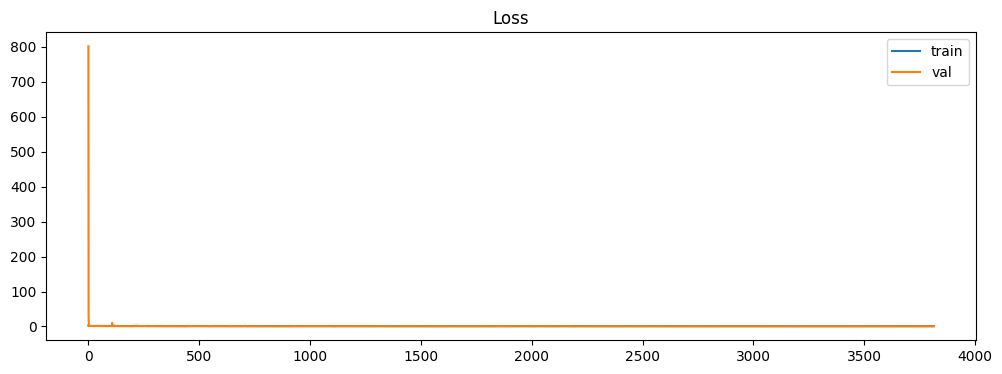

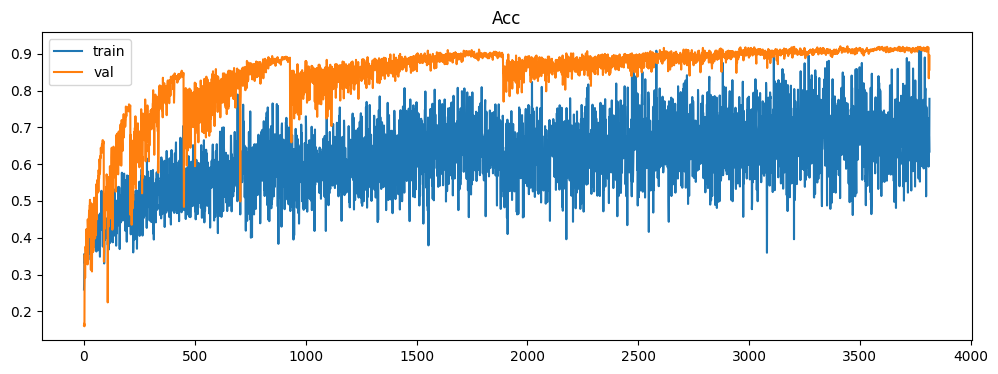

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(range(len(train_loss_list)), train_loss_list)
plt.plot(range(len(val_loss_list)), val_loss_list)
plt.legend(['train', 'val'])
plt.title('Loss')
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(range(len(train_acc_list)), train_acc_list)
plt.plot(range(len(val_acc_list)), val_acc_list)
plt.legend(['train', 'val'])
plt.title('Acc')
plt.show()

finish training your classifier, next you should use this classifer to predict unlabel images with pseduo label.

## Step2: Use unlabeled data to enhance model performance

In [ ]:
# load the trained classifier weights
ckpt = torch.load(SUPERVISED_CKPT, map_location=device)
model.load_state_dict(ckpt)

In [ ]:
# create a unlabeled data set list, we will use it later
unlabeled_set_list = []
for img in unlabeled_set:
    unlabeled_set_list.append(img)

print("Unlabeled pool size:", len(unlabeled_set_list))

Unlabeled pool size: 1202


### Use the trained classifier to generates pseudo-labels of a dataset.
用目前訓練好的模型，幫「未標籤圖片 (unlabeled data)」自動打上 pseudo label（偽標籤），
再把這些資料加回訓練集中，讓模型能用更多資料繼續學習。

In [ ]:
from tqdm import tqdm
import torch.nn as nn
from torch.utils.data import ConcatDataset, DataLoader, TensorDataset # <-- 確保有 import DataLoader 和 TensorDataset

###########################################################
#   You can adjust the threshold to get better result !   #
###########################################################

def get_pseudo_labels(model, unlabeled_data_list, threshold, top_k):
    model.eval()
    # imgs_keep = [] 
    # labels_keep = [] 
    # remove_index = []
    soft_max = nn.Softmax(dim=1)
    
    # 這個 list 會儲存所有滿足 threshold 條件的樣本
    confident_samples = []
    
    # 使用 DataLoader 進行批次預測，速度遠快於單張處理
    temp_loader = DataLoader(unlabeled_data_list, batch_size=batch_size * 2, shuffle=False, num_workers=num_workers)

    with torch.no_grad():
        current_idx = 0
        # 迴圈，改為批次處理
        for images_batch in tqdm(temp_loader, desc="Pseudo-labeling", leave=False):
            images_batch = images_batch.to(device)
            #####################################################################################
            #     TODO:                                                                         #
            #     1. Foward the data, Using torch.no_grad() accelerates the forward process     #
            #     2. obtain the probability distributions by applying softmax on logits         #
            #     3. Filter the data with threshold                                             #
            #     4. Combine the labeled training data with the pseudo-labeled data             #
            #        to construct a new training set. then removed                              #
            #     5. the unlabeled data from unlabeled_set_list                                 #
            #     hint: ConcatDataset                                                           #
            #####################################################################################
            outputs = model(images_batch)
            probs = soft_max(outputs)
            max_probs, preds = torch.max(probs, dim=1)
            
            
            for img, pred, prob in zip(images_batch, preds, max_probs):
                if prob.item() >= threshold:
                    # 如果信心度足夠高，就加入候選清單 (包含原始 index)
                    confident_samples.append((img.cpu(), pred.cpu(), prob.cpu(), current_idx))
                current_idx += 1
            #####################################################################################
            #                           End of your code                                        #
            #####################################################################################

    # 依照信心度從高到低排序，並選取 Top-K
    confident_samples.sort(key=lambda x: x[2], reverse=True)
    top_samples = confident_samples[:top_k]
    
   
    if top_samples:
        pseudo_imgs   = torch.stack([s[0] for s in top_samples])
        pseudo_labels = torch.tensor([s[1] for s in top_samples], dtype=torch.long)
        indices_to_remove = [s[3] for s in top_samples]
        pseudo_dataset = TensorDataset(pseudo_imgs, pseudo_labels)
        taken = len(pseudo_dataset)
    else:
        pseudo_dataset = None
        taken = 0
        indices_to_remove = []

    # 依照你的要求，保留 print 格式
    remaining_count = len(unlabeled_data_list) - taken
    print(f"Labeled {taken} images this round. Remaining unlabeled: {remaining_count}")

    # Clear GPU cache to free memory
    torch.cuda.empty_cache()

    
    return pseudo_dataset, sorted(indices_to_remove, reverse=True)

## Redeifine your optimizer if you want

In [ ]:
import torch.nn as nn
import torch.optim as optim

################################################################################
# TODO: Define loss and optmizer functions                                     #
# Try any loss or optimizer function and learning rate to get better result    #
# hint: torch.nn and torch.optim                                               #
################################################################################
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer = optim.AdamW(model.parameters(), lr=4e-5, weight_decay=5e-5) 
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=20, T_mult=1) 
################################################################################
#                               End of your code                               #
################################################################################
criterion = criterion.to(device)

### Train the model

Let's define train function.  

Use the **get_pseudo_labels** function to get the new training set, then construct a new data loader for training.

It will iterate input data 1 epoch and update model with optmizer.  

Finally, calculate mean loss and total accuracy.

In [ ]:
import sys
import os 
from torch.utils.data import ConcatDataset, DataLoader

sys.setrecursionlimit(1000000)

#########################################################################################################
#         You can adjust those hyper parameters like epochs or threshold for training                   #
#########################################################################################################

n_epochs = 120
relabel_interval = 10 
top_k = 100           
log_interval = 10
SELF_TRAIN_CKPT = 'self_training_final.pt'


SUPERVISED_CKPT = 'supurvised.pt' 
print(f"Loading best supervised model from: {SUPERVISED_CKPT}")

if not os.path.exists(SUPERVISED_CKPT):
    print(f"!!! ERROR: Supervised checkpoint file '{SUPERVISED_CKPT}' not found. Please run Phase 1 first. !!!")
    best_acc = 0.0
else:
    ckpt = torch.load(SUPERVISED_CKPT, map_location=device)
    
    if isinstance(ckpt, dict) and 'model_state_dict' in ckpt:
        print("Detected checkpoint dictionary format. Loading weights...")
        model.load_state_dict(ckpt['model_state_dict'])
        best_acc = ckpt.get('best_acc', 0.0)
    else:
        print("Detected direct state_dict format. Loading weights...")
        model.load_state_dict(ckpt)
        best_acc = 0.0
    
    if best_acc == 0.0:
        print("Evaluating initial model to determine starting best_acc...")
        initial_acc, _ = val(val_loader, model, criterion)
        best_acc = initial_acc
    
    print(f"Initial model loaded. Val Acc: {best_acc:.4f}. Starting self-training.")

# Initialize with original labeled data
current_train_dataset = train_set
all_pseudo_datasets = []

for epoch in range(1, n_epochs + 1):
    #########################################################################################################
    #    TODO:                                                                                              #
    #    In each epoch, relabel the unlabeled dataset for semi-supervised learning.                         #
    #    1. Obtain pseudo-labels for unlabeled data using trained model.(use get_pseudo_labels function)    #
    #    2. Construct a new dataset and a data loader for training.                                         #
    #    You can try different way to use the get_pseudo_label function maybe will get the better result.   #
    #########################################################################################################
    
    if epoch % relabel_interval == 1 and len(unlabeled_set_list) > 0:
        # 動態閾值：從寬鬆開始，隨著模型變強而變嚴格
        current_threshold = min(0.95, 0.80 + (epoch // 25) * 0.05)
        print(f"\nUsing dynamic threshold for this round: {current_threshold:.2f}")
        
        pseudo_dataset, indices_to_remove = get_pseudo_labels(model, unlabeled_set_list, current_threshold, top_k)
        
        if pseudo_dataset and len(pseudo_dataset) > 0:
            all_pseudo_datasets.append(pseudo_dataset)
            current_train_dataset = ConcatDataset([train_set] + all_pseudo_datasets)
            
            for idx in indices_to_remove:
                unlabeled_set_list.pop(idx)

    # 每次都用最新的 current_train_dataset 建立 loader
    train_loader_ssl = DataLoader(
        current_train_dataset,
        shuffle=True,
        **loader_kwargs
    )
    #########################################################################################################
    #                                          End of your code                                             #
    #########################################################################################################

    try:
        # ---------- Training using the train function from above ----------
        train_acc, train_loss = train(train_loader_ssl, model, criterion, optimizer, epoch=epoch, total_epochs=n_epochs)

        # ---------- Validation ----------
        valid_acc, valid_loss = val(val_loader, model, criterion, epoch=epoch, total_epochs=n_epochs)

        # Log every log_interval epochs like supervised training
        if (epoch % log_interval == 0) or (epoch == n_epochs): # 最後一輪也印出
            lr = optimizer.param_groups[0]['lr']
            total_pseudo = sum(len(dataset) for dataset in all_pseudo_datasets)
            print('=' * 20, f'Epoch {epoch}/{n_epochs}', '=' * 20)
            print('Train Acc: {:.6f} | Train Loss: {:.6f}'.format(train_acc, train_loss))
            print('  Val Acc: {:.6f} |   Val Loss: {:.6f} | LR: {:.6f}'.format(valid_acc, valid_loss, lr))
            print('Dataset Size: {} (original: {}, pseudo: {})'.format(len(current_train_dataset), len(train_set), total_pseudo))

        if valid_acc > best_acc:
            best_acc = valid_acc
            torch.save(model.state_dict(), SELF_TRAIN_CKPT)
            if (epoch % log_interval != 0):
                print('[{:03d}/{:03d}] saving model with acc {:.3f}'.format(epoch, n_epochs, best_acc))

    except RuntimeError as e:
        print(f"CUDA error during training epoch {epoch+1}: {e}")
        torch.cuda.empty_cache()

        if "out of memory" in str(e).lower():
            new_batch_size = max(loader_kwargs['batch_size'] // 2, 1)
            loader_kwargs['batch_size'] = new_batch_size
            print(f"RuntimeError: Reducing batch size to {new_batch_size}")
            
    scheduler.step()
#########################################################################################################
#                               End of your code                                                        #
#########################################################################################################

Loading best supervised model from: supurvised.pt
Detected direct state_dict format. Loading weights...
Evaluating initial model to determine starting best_acc...


Val:   0%|          | 0/6 [00:00<?, ?it/s]

Initial model loaded. Val Acc: 0.8569. Starting self-training.

Using dynamic threshold for this round: 0.80


Labeled 100 images this round. Remaining unlabeled: 1102


[001/120] saving model with acc 0.906


...

==================== Epoch 100/120 ====================
Train Acc: 0.713906 | Train Loss: 0.770938
  Val Acc: 0.917404 |   Val Loss: 0.492662 | LR: 0.000000
Dataset Size: 1503 (original: 1200, pseudo: 303)

Using dynamic threshold for this round: 0.95


Labeled 0 images this round. Remaining unlabeled: 899


==================== Epoch 110/120 ====================
Train Acc: 0.611444 | Train Loss: 0.747727
  Val Acc: 0.918879 |   Val Loss: 0.499950 | LR: 0.000023
Dataset Size: 1503 (original: 1200, pseudo: 303)

Using dynamic threshold for this round: 0.95


Labeled 0 images this round. Remaining unlabeled: 899


==================== Epoch 120/120 ====================
Train Acc: 0.779774 | Train Loss: 0.717129
  Val Acc: 0.915929 |   Val Loss: 0.488766 | LR: 0.000000
Dataset Size: 1503 (original: 1200, pseudo: 303)


### Predict Result

Predict the labesl based on testing set. Upload to [Kaggle](https://www.kaggle.com/t/c835441092034e459933e0a304e469e1).

**How to upload**

1. Click the folder icon in the left hand side of Colab.
2. Right click "result.csv". Select "Download"
3. To kaggle. Click "Submit Predictions"
4. Upload the result.csv
5. System will automaticlaly calculate the accuracy of 50% dataset and publish this result to leaderboard.

In [ ]:
# if you wanna load previous best model
ckpt = torch.load('self_training_final.pt', map_location=device)
model.load_state_dict(ckpt)

<All keys matched successfully>

In [ ]:
test_set = FlowerData(data_folder, split='test', mode='test', transform=transforms_test)
test_loader = DataLoader(
    test_set,
    batch_size=batch_size,
    num_workers=num_workers,
    shuffle=False,
    pin_memory=torch.cuda.is_available()
)

In [ ]:
def predict(input_data, model):
    model.eval()
    output_list = []
    with torch.no_grad():
        for images in input_data:
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            output_list.extend(predicted.to('cpu').numpy().tolist())
    return output_list

In [ ]:
pred_indices = predict(test_loader, model)

with open('result.csv', 'w', newline='') as csvFile:
    writer = csv.DictWriter(csvFile, fieldnames=['ID', 'label'])
    writer.writeheader()
    for filename, pred in zip(test_set.paths, pred_indices):
        filename = osp.basename(filename)  # Extract just the filename
        writer.writerow({'ID': filename, 'label': CLASS_NAMES[int(pred)]})

print("Saved predictions to result.csv")

Saved predictions to result.csv
